# MindGlide quickstart

**Brain MRI segmentation for multiple sclerosis — any modality, any quality — in one command.**

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MS-PINPOINT/mindGlide/blob/main/examples/mindglide_quickstart.ipynb)
[![PyPI](https://img.shields.io/pypi/v/mindglide)](https://pypi.org/project/mindglide/)

[GitHub](https://github.com/MS-PINPOINT/mindGlide) ·
[Paper (*Nature Communications*, 2025)](https://www.nature.com/articles/s41467-025-58274-8) ·
[PyPI](https://pypi.org/project/mindglide/) ·
[Model on Hugging Face](https://huggingface.co/MS-PINPOINT/mindglide)

This notebook takes about five minutes end-to-end. It will:

1. install MindGlide,
2. download a public T1-weighted template scan (MNI152),
3. segment it into 20 brain regions with a single CLI call,
4. overlay the segmentation on the scan with `nilearn`,
5. extract per-region volumes (mm³) and chart them.

No data of your own is needed — everything below is public.

## 1 · Install

One pip package. The cell only installs what is missing, so re-running it (or
executing this notebook in CI) is fast and safe.

In [ ]:
import importlib.util

missing = [pkg for pkg in ("mindglide", "nilearn", "matplotlib")
           if importlib.util.find_spec(pkg) is None]
if missing:
    pkgs = " ".join(missing)
    %pip install -q {pkgs}
    print(f"Installed: {pkgs}")
else:
    print("All requirements already installed — skipping pip.")

## 2 · Get a scan

We use the public 1 mm MNI152 T1-weighted template from
[TemplateFlow](https://www.templateflow.org/) (~13 MB). To use your own scan
instead, just point `T1_PATH` at any NIfTI file.

In [ ]:
import os
import urllib.request

T1_PATH = "tpl-MNI152NLin2009cAsym_res-01_T1w.nii.gz"
URL = ("https://templateflow.s3.amazonaws.com/tpl-MNI152NLin2009cAsym/"
       "tpl-MNI152NLin2009cAsym_res-01_T1w.nii.gz")

if not os.path.exists(T1_PATH):
    print("Downloading MNI152 template ...")
    urllib.request.urlretrieve(URL, T1_PATH)
print(f"{T1_PATH}: {os.path.getsize(T1_PATH) / 1e6:.1f} MB")

## 3 · Segment

One command. In a terminal this is simply:

```bash
mindglide -i scan.nii.gz -o scan_seg.nii.gz
```

MindGlide picks the compute device automatically — a working GPU if present
(seconds per scan), otherwise CPU (a few minutes). The trained model (~123 MB)
downloads from Hugging Face and is cached on first run.

In [ ]:
import sys
import time

SEG_PATH = "mni_seg.nii.gz"

start = time.time()
# Same as the `mindglide` console command, pinned to this notebook's Python.
!{sys.executable} -m mindglide -i {T1_PATH} -o {SEG_PATH}
print(f"\nSegmentation finished in {time.time() - start:.0f} s -> {SEG_PATH}")

## 4 · Visualize

The segmentation is a NIfTI label map on the same grid as the input scan.
Each of the 20 labels has a fixed reference color; we build a matplotlib
`ListedColormap` from that palette (background transparent) so every plot in
this notebook uses identical colors.

In [ ]:
import numpy as np
from matplotlib.colors import ListedColormap

# Label id -> (region name, reference RGB). This is MindGlide's fixed palette.
MINDGLIDE_PALETTE = {
    0:  ("Background",                      (0, 0, 0)),
    1:  ("CSF",                             (108, 180, 255)),
    2:  ("Ventricles_3_4_5",                (42, 110, 235)),
    3:  ("DGM",                             (170, 80, 205)),
    4:  ("Pons",                            (255, 170, 60)),
    5:  ("Brainstem",                       (230, 115, 25)),
    6:  ("Cerebellum",                      (76, 187, 100)),
    7:  ("Temporal_lobe",                   (235, 205, 60)),
    8:  ("Temporal_horn_lateral_ventricle", (90, 220, 220)),
    9:  ("Lateral_ventricle",               (25, 70, 190)),
    10: ("Optic_chiasm",                    (255, 120, 185)),
    11: ("Cerebellar_vermis",               (25, 130, 65)),
    12: ("Corpus_callosum",                 (205, 165, 95)),
    13: ("White_matter",                    (245, 245, 235)),
    14: ("Frontal_lobe_GM",                 (240, 140, 115)),
    15: ("Limbic_cortex_GM",                (165, 110, 55)),
    16: ("Parietal_lobe_GM",                (130, 90, 235)),
    17: ("Occipital_lobe_GM",               (95, 200, 160)),
    18: ("Lesion",                          (230, 30, 30)),
    19: ("Ventral_diencephalon",            (255, 220, 120)),
}

rgba = np.array([[r / 255, g / 255, b / 255, 1.0]
                 for _, (r, g, b) in MINDGLIDE_PALETTE.values()])
rgba[0, 3] = 0.0  # label 0 (background) is fully transparent
mindglide_cmap = ListedColormap(rgba, name="mindglide")
print(f"Colormap ready: {mindglide_cmap.N} colors")

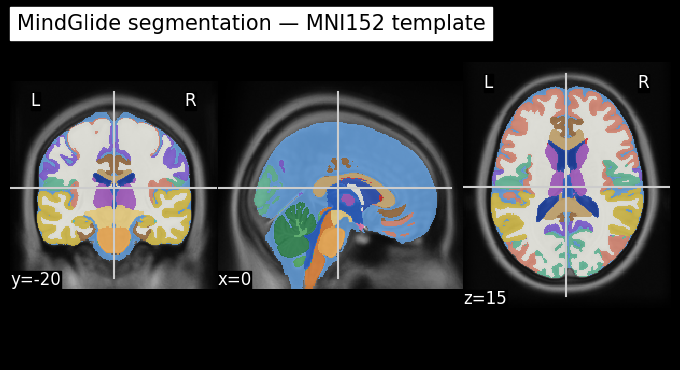

In [ ]:
from nilearn import plotting

plotting.plot_roi(
    SEG_PATH,
    bg_img=T1_PATH,
    cmap=mindglide_cmap,
    vmin=0,
    vmax=19,
    alpha=0.7,
    cut_coords=(0, -20, 15),
    colorbar=False,  # label ids are not a scale; the volume chart below is the legend
    title="MindGlide segmentation — MNI152 template",
)
plotting.show()

## 5 · Per-region volumes

`mindglide-volumes` turns any segmentation into a per-region volume table
(mm³) — the numbers you would feed into an analysis. Regions absent from the
scan get an explicit zero.

In [ ]:
VOL_CSV = "mni_volumes.csv"

# Same as the `mindglide-volumes` console command.
!{sys.executable} -m mindglide.volumes {SEG_PATH} --out-csv {VOL_CSV}

import pandas as pd

volumes = pd.read_csv(VOL_CSV)
volumes.sort_values("Volume_mm3", ascending=False).reset_index(drop=True)

And the same table as a chart — one bar per segmented region, colored with the
palette above so it doubles as a legend for the overlay.

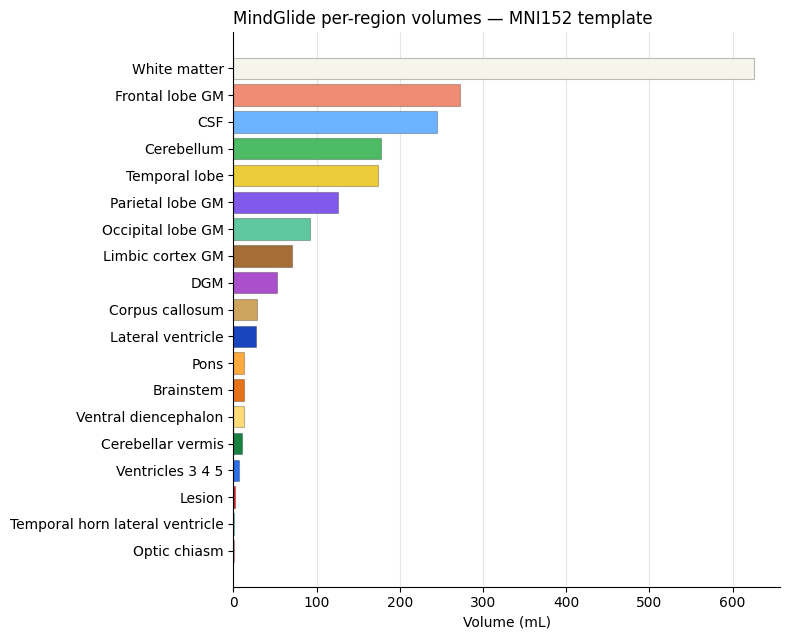

In [ ]:
import matplotlib.pyplot as plt

regions = volumes[(volumes["Label_ID"] != 0) & (volumes["Volume_mm3"] > 0)]
regions = regions.sort_values("Volume_mm3")  # largest region ends up on top

bar_colors = [tuple(c / 255 for c in MINDGLIDE_PALETTE[label][1])
              for label in regions["Label_ID"]]
names = regions["Region_Name"].str.replace("_", " ")

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(names, regions["Volume_mm3"] / 1000, color=bar_colors,
        edgecolor="#00000040", linewidth=0.8)
ax.set_xlabel("Volume (mL)")
ax.set_title("MindGlide per-region volumes — MNI152 template", loc="left")
ax.grid(axis="x", color="0.90", linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()

## What to try next

- **Your own scans** — `mindglide -i scan.nii.gz -o scan_seg.nii.gz` works on
  any modality (T1, T2, FLAIR, PD ...), research or clinical quality.
- **A whole folder** — `mindglide -i scans/ -o segs/` segments every NIfTI file
  in it (add `--resume` to skip scans already done).
- **MS lesions** — on scans from people with multiple sclerosis, label 18
  (`Lesion`, red) delineates white-matter lesions.
- **Options** — `--device cpu|cuda|mps`, `--sw-batch-size`, offline
  `--model-path`; see `mindglide --help` or the
  [README](https://github.com/MS-PINPOINT/mindGlide#options).
- **The model itself** — weights and card at
  [huggingface.co/MS-PINPOINT/mindglide](https://huggingface.co/MS-PINPOINT/mindglide).

Questions or issues? Open one on
[GitHub](https://github.com/MS-PINPOINT/mindGlide/issues).

### Citation

If you use MindGlide, please cite:

> Goebl P, Wingrove J, Abdelmannan O, *et al.* Enabling new insights from old
> scans by repurposing clinical MRI archives for multiple sclerosis research.
> *Nature Communications*. 2025;16(1):3149.
> doi:[10.1038/s41467-025-58274-8](https://doi.org/10.1038/s41467-025-58274-8)